# IEG Assignment – Interannual Variability of Solar and Wind Generation
This notebook runs the capacity expansion optimization for each weather year (2020–2023)
and plots the average capacity and variability for each generator across years.

## 1. Imports

In [1]:
import pandas as pd
pd.options.future.infer_string = False

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add python_codes folder to path (same as in the original notebook)
module_dir = Path.cwd() / 'python_codes'
if str(module_dir) not in sys.path:
    sys.path.append(str(module_dir))

from python_codes.Abstract_model import CapacityExpansionInput, optimize_capacity_expansion

print('Setup complete.')

Setup complete.


## 2. Load Technology Costs
Same cost parameters as the original notebook.

In [2]:
cost_df = pd.read_csv('./Data/Techs_cost_FOM_&_Fuel_cost.csv')

tech_mapping = {
    'Wind':    ['Wind onshore', 'Wind offshore'],
    'Solar':   ['Solar PV rooftop', 'Solar PV utility'],
    'Hydro':   ['Hydro reservoir', 'Run-of-river', 'Pumped hydro storage'],
    'CCGT':    ['Open cycle gas turbine (OCGT)'],
    'Coal':    ['Coal'],
    'Nuclear': ['Nuclear'],
}

def aggregate_costs(tech_name, cost_df, tech_mapping):
    matching_rows = cost_df[cost_df['Technology'].isin(tech_mapping.get(tech_name, []))]
    if len(matching_rows) == 0:
        return None
    row = matching_rows.iloc[0]
    capcost_mw  = row['Annualized Cost (€/kW/a)'] * 1000
    fixed_cost  = capcost_mw * (row['FOM (%/a)'] / 100.0)
    fuel_cost   = row['Fuel Cost (€/MWh)']
    return {'variable_cost': fuel_cost, 'fixed_cost': fixed_cost,
            'min_cap': 0, 'max_cap': 100_000}

tech_params_base = {}
for tech in ['Wind', 'Solar', 'Hydro', 'CCGT', 'Coal', 'Nuclear']:
    p = aggregate_costs(tech, cost_df, tech_mapping)
    if p:
        tech_params_base[tech] = p
        print(f"{tech:8s}: Fixed = €{p['fixed_cost']:,.0f}/MW/yr,  Fuel = €{p['variable_cost']:.2f}/MWh")

Wind    : Fixed = €2,513/MW/yr,  Fuel = €0.00/MWh
Solar   : Fixed = €1,029/MW/yr,  Fuel = €0.00/MWh
Hydro   : Fixed = €1,020/MW/yr,  Fuel = €0.00/MWh
CCGT    : Fixed = €1,041/MW/yr,  Fuel = €30.00/MWh
Coal    : Fixed = €5,238/MW/yr,  Fuel = €61.52/MWh
Nuclear : Fixed = €7,926/MW/yr,  Fuel = €8.50/MWh


## 3. Helper Functions

In [3]:
# --------------------------------------------------------------------------
# Load installed capacity for a given year from the ENTSO-E CSV
# --------------------------------------------------------------------------
def load_installed_capacity(year):
    """Return dict with Wind, Solar, Hydro installed capacity (MW) for the year."""
    path = f'./Data/Interannual_data/export_InstalledCapacityGenerationTotal_{year}.csv'
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    df['Production Type'] = df['Production Type'].str.strip()
    df['Installed Capacity (MW)'] = pd.to_numeric(
        df['Installed Capacity (MW)'].astype(str).str.replace(',', '.'), errors='coerce'
    )

    wind_cap  = df[df['Production Type'] == 'Wind Onshore']['Installed Capacity (MW)'].sum()
    solar_cap = df[df['Production Type'] == 'Solar']['Installed Capacity (MW)'].sum()
    hydro_cap = (
        df[df['Production Type'].isin(['Hydro Run-of-river and pondage',
                                        'Hydro Water Reservoir'])]['Installed Capacity (MW)'].sum()
    )
    print(f"  {year} capacities → Wind: {wind_cap:,.0f} MW | Solar: {solar_cap:,.0f} MW | Hydro: {hydro_cap:,.0f} MW")
    return {'Wind': wind_cap, 'Solar': solar_cap, 'Hydro': hydro_cap}


# --------------------------------------------------------------------------
# Load hourly generation by technology from ENTSO-E xlsx
# --------------------------------------------------------------------------
def load_generation_xlsx(year):
    """Return DataFrame with hourly generation per technology for the year."""
    path = f'./Data/Interannual_data/generation_by_tech_{year}.xlsx'
    # Skip the first 4 header rows (title, subtitle, period, blank)
    df = pd.read_excel(path, sheet_name=0, header=[4, 5], engine='openpyxl')

    # Flatten multi-level columns
    df.columns = [' '.join([str(c).strip() for c in col if 'Unnamed' not in str(c)]).strip()
                  for col in df.columns.values]

    # First column is the time interval string
    df = df.rename(columns={df.columns[0]: 'MTU'})
    df = df.dropna(subset=['MTU'])
    df = df[df['MTU'].astype(str).str.contains(r'\d{2}/\d{2}/\d{4}', na=False)]

    # Parse datetime from 'DD/MM/YYYY HH:MM:SS - ...' format
    df['datetime'] = pd.to_datetime(
        df['MTU'].astype(str).str.split(' - ').str[0].str.strip()
        .str.replace(r' \(CET\)| \(CEST\)', '', regex=True),
        format='%d/%m/%Y %H:%M:%S'
    )
    df = df.set_index('datetime').sort_index()

    # Convert all columns to numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace('n/e', '0').str.replace(' ', ''),
                                errors='coerce').fillna(0.0).clip(lower=0)

    # Map column names to technology keys
    col_map = {}
    for col in df.columns:
        cl = col.lower()
        if 'wind onshore' in cl:              col_map[col] = 'Wind'
        elif 'solar' in cl:                   col_map[col] = 'Solar'
        elif 'hydro run' in cl:               col_map[col] = 'Hydro'
        elif 'hydro water' in cl:             col_map[col] = 'Hydro'
        elif 'fossil gas' in cl:              col_map[col] = 'CCGT'
        elif 'fossil hard coal' in cl:        col_map[col] = 'Coal'
        elif 'nuclear' in cl:                 col_map[col] = 'Nuclear'

    df = df.rename(columns=col_map)

    # Aggregate duplicate tech columns
    techs = ['Wind', 'Solar', 'Hydro', 'CCGT', 'Coal', 'Nuclear']
    result = pd.DataFrame(index=df.index)
    for tech in techs:
        cols = [c for c in df.columns if c == tech]
        result[tech] = df[cols].sum(axis=1) if cols else 0.0

    result['demand'] = result.clip(lower=0).sum(axis=1)
    print(f"  {year} generation data: {len(result)} hours")
    return result


# --------------------------------------------------------------------------
# Build capacity factors and run optimization for one year
# --------------------------------------------------------------------------
def run_optimization_for_year(year, solver='highs'):
    print(f"\n{'='*60}")
    print(f"Processing year {year}")
    print(f"{'='*60}")

    # 1. Installed capacities
    caps = load_installed_capacity(year)

    # 2. Hourly generation profiles
    gen  = load_generation_xlsx(year)

    # 3. Capacity factors (p.u.) = generation / installed capacity
    renewable_profiles = {}
    for tech in ['Wind', 'Solar', 'Hydro']:
        cap = caps[tech]
        cf  = (gen[tech].values / cap).clip(0, 1) if cap > 0 else np.zeros(len(gen))
        renewable_profiles[tech] = cf
        print(f"  {tech} avg CF: {cf.mean():.3f}  |  peak CF: {cf.max():.3f}")

    # 4. Demand = sum of all generation
    demand = gen['demand'].values
    print(f"  Demand: avg {demand.mean():,.0f} MW | peak {demand.max():,.0f} MW")

    # 5. Tech params: apply hydro capacity constraint
    import copy
    tech_params = copy.deepcopy(tech_params_base)
    solar_cap_limit = 50000  # 50 GW in MW
    wind_cap_limit = 50000   # 50 GW in MW
    hydro_cap_limit = 17097  # 17 GW in MW
    tech_params['Solar']['max_cap'] = solar_cap_limit
    tech_params['Wind']['max_cap'] = wind_cap_limit
    tech_params['Hydro']['max_cap'] = hydro_cap_limit
    
    # 6. Build input and run
    data = CapacityExpansionInput(
        hourly_demand=demand,
        tech_params=tech_params,
        renewable_profiles=renewable_profiles,
    )

    result = optimize_capacity_expansion(data, solver_name=solver)
    print(f"  Status: {result.status} | Total cost: €{result.objective_value:,.0f}")
    print(f"  Optimal capacities: { {k: f'{v:,.0f} MW' for k,v in result.optimal_capacities.items()} }")
    return result.optimal_capacities

print('Helper functions defined.')

Helper functions defined.


## 4. Run Optimization for Each Year (2020–2023)
> Change `solver` to `'gurobi'` if you have a valid Gurobi licence.

In [4]:
SOLVER = 'highs'
YEARS  = [2020, 2021, 2022, 2023]

results_per_year = {}
for yr in YEARS:
    results_per_year[yr] = run_optimization_for_year(yr, solver=SOLVER)

print('\nAll years optimized!')


Processing year 2020
  2020 capacities → Wind: 24,447 MW | Solar: 8,466 MW | Hydro: 20,294 MW
  2020 generation data: 8784 hours
  Wind avg CF: 0.248  |  peak CF: 0.795
  Solar avg CF: 0.268  |  peak CF: 1.000
  Hydro avg CF: 0.378  |  peak CF: 1.000
  Demand: avg 29,951 MW | peak 45,589 MW


Index(['electricity'], dtype='object', name='name')


Optimizing with highs...


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 123.70it/s]
INFO:linopy.io: Writing time: 0.4s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52710 primals, 114204 duals
Objective: 6.75e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


✓ Optimization complete

  Checking network contents:
    generators index: ['Wind', 'Solar', 'Hydro', 'CCGT', 'Coal', 'Nuclear']
    Available columns in generators:
      - bus
      - control
      - type
      - p_nom
      - p_nom_mod
      - p_nom_extendable
      - p_nom_min
      - p_nom_max
      - p_nom_set
      - p_min_pu
      - p_max_pu
      - p_set
      - p_init
      - e_sum_min
      - e_sum_max
      - q_set
      - sign
      - carrier
      - marginal_cost
      - marginal_cost_quadratic
      - active
      - build_year
      - lifetime
      - capital_cost
      - overnight_cost
      - discount_rate
      - fom_cost
      - efficiency
      - committable
      - start_up_cost
      - shut_down_cost
      - stand_by_cost
      - min_up_time
      - min_down_time
      - up_time_before
      - down_time_before
      - ramp_limit_up
      - ramp_limit_down
      - ramp_limit_start_up
      - ramp_limit_shut_down
      - weight
      - p_nom_opt

  Checking solutio

...

✓ Optimization complete

  Checking network contents:
    generators index: ['Wind', 'Solar', 'Hydro', 'CCGT', 'Coal', 'Nuclear']
    Available columns in generators:
      - bus
      - control
      - type
      - p_nom
      - p_nom_mod
      - p_nom_extendable
      - p_nom_min
      - p_nom_max
      - p_nom_set
      - p_min_pu
      - p_max_pu
      - p_set
      - p_init
      - e_sum_min
      - e_sum_max
      - q_set
      - sign
      - carrier
      - marginal_cost
      - marginal_cost_quadratic
      - active
      - build_year
      - lifetime
      - capital_cost
      - overnight_cost
      - discount_rate
      - fom_cost
      - efficiency
      - committable
      - start_up_cost
      - shut_down_cost
      - stand_by_cost
      - min_up_time
      - min_down_time
      - up_time_before
      - down_time_before
      - ramp_limit_up
      - ramp_limit_down
      - ramp_limit_start_up
      - ramp_limit_shut_down
      - weight
      - p_nom_opt

  Checking solutio

Index(['electricity'], dtype='object', name='name')


Optimizing with highs...


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 118.74it/s]
INFO:linopy.io: Writing time: 0.3s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 210246 primals, 455532 duals
Objective: 1.73e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


✓ Optimization complete

  Checking network contents:
    generators index: ['Wind', 'Solar', 'Hydro', 'CCGT', 'Coal', 'Nuclear']
    Available columns in generators:
      - bus
      - control
      - type
      - p_nom
      - p_nom_mod
      - p_nom_extendable
      - p_nom_min
      - p_nom_max
      - p_nom_set
      - p_min_pu
      - p_max_pu
      - p_set
      - p_init
      - e_sum_min
      - e_sum_max
      - q_set
      - sign
      - carrier
      - marginal_cost
      - marginal_cost_quadratic
      - active
      - build_year
      - lifetime
      - capital_cost
      - overnight_cost
      - discount_rate
      - fom_cost
      - efficiency
      - committable
      - start_up_cost
      - shut_down_cost
      - stand_by_cost
      - min_up_time
      - min_down_time
      - up_time_before
      - down_time_before
      - ramp_limit_up
      - ramp_limit_down
      - ramp_limit_start_up
      - ramp_limit_shut_down
      - weight
      - p_nom_opt

  Checking solutio

## 5. Summary Table

In [5]:
techs = ['Wind', 'Solar', 'Hydro', 'CCGT', 'Coal', 'Nuclear']

cap_df = pd.DataFrame(
    {yr: {tech: results_per_year[yr].get(tech, 0) for tech in techs} for yr in YEARS}
).T
cap_df.index.name = 'Year'

print('Optimal capacities (MW) by year:')
print(cap_df.round(0).to_string())

print('\nStatistics across years:')
stats = pd.DataFrame({'Mean (MW)': cap_df.mean(), 'Std (MW)': cap_df.std(),
                      'Min (MW)':  cap_df.min(),  'Max (MW)': cap_df.max()})
print(stats.round(0).to_string())

Optimal capacities (MW) by year:
         Wind    Solar    Hydro    CCGT  Coal  Nuclear
Year                                                  
2020  50000.0  50000.0  17097.0  7986.0  -0.0  15128.0
2021  50000.0  50000.0  17097.0  8968.0  -0.0  16538.0
2022  50000.0  50000.0  17097.0  7610.0  -0.0  20307.0
2023  50000.0  50000.0  17097.0  2892.0  -0.0  17516.0

Statistics across years:
         Mean (MW)  Std (MW)  Min (MW)  Max (MW)
Wind       50000.0       0.0   50000.0   50000.0
Solar      50000.0       0.0   50000.0   50000.0
Hydro      17097.0       0.0   17097.0   17097.0
CCGT        6864.0    2709.0    2892.0    8968.0
Coal           0.0       0.0      -0.0      -0.0
Nuclear    17372.0    2188.0   15128.0   20307.0


## 6. Chart – Optimal Capacity per Technology per Year
Bar chart with one group per year, showing all technologies. Error bars indicate interannual variability.

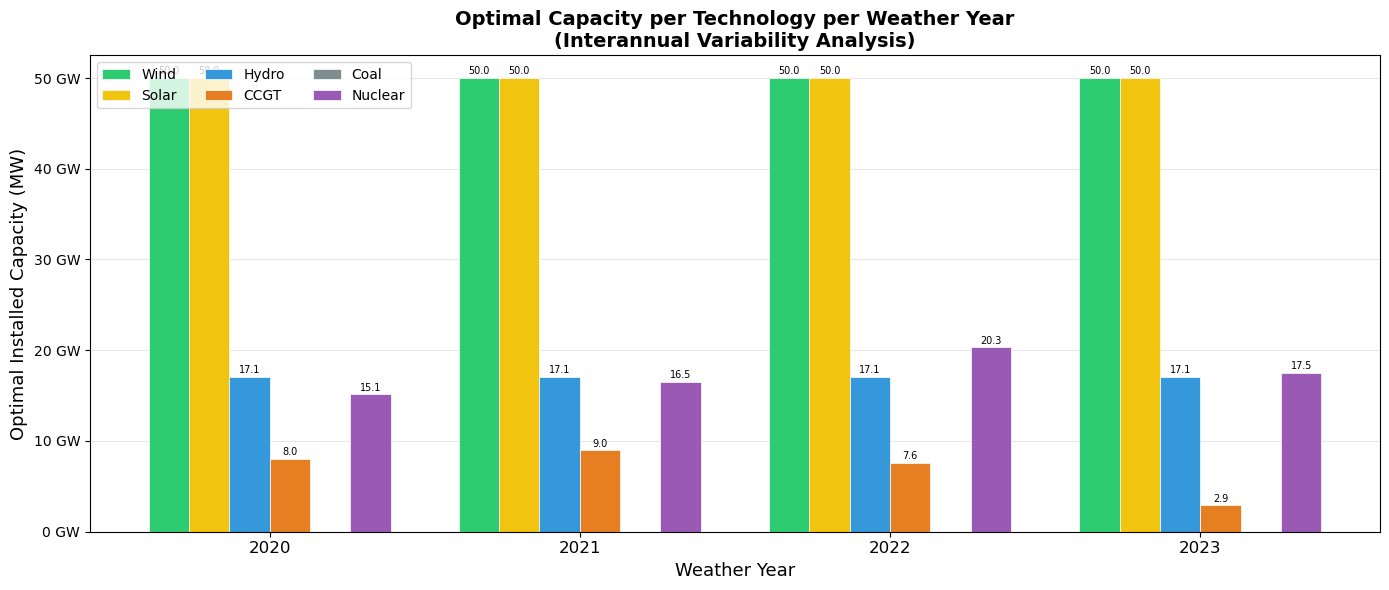

Chart saved.


In [6]:
color_map = {
    'Wind':    '#2ecc71',
    'Solar':   '#f1c40f',
    'Hydro':   '#3498db',
    'CCGT':    '#e67e22',
    'Coal':    '#7f8c8d',
    'Nuclear': '#9b59b6',
}

x      = np.arange(len(YEARS))
n_tech = len(techs)
width  = 0.13          # width of each bar
offsets = np.linspace(-(n_tech-1)/2, (n_tech-1)/2, n_tech) * width

fig, ax = plt.subplots(figsize=(14, 6))

for i, tech in enumerate(techs):
    values = [results_per_year[yr].get(tech, 0) for yr in YEARS]
    bars = ax.bar(x + offsets[i], values, width=width,
                  label=tech, color=color_map.get(tech, 'gray'),
                  edgecolor='white', linewidth=0.5)

    # Annotate bar values
    for bar, val in zip(bars, values):
        if val > 500:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                    f'{val/1000:.1f}', ha='center', va='bottom',
                    fontsize=7, color='black')

ax.set_xticks(x)
ax.set_xticklabels([str(yr) for yr in YEARS], fontsize=12)
ax.set_xlabel('Weather Year', fontsize=13)
ax.set_ylabel('Optimal Installed Capacity (MW)', fontsize=13)
ax.set_title('Optimal Capacity per Technology per Weather Year\n(Interannual Variability Analysis)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, ncol=3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f} GW'))
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('./Plots/Interannual_variability/interannual_capacity_barchart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

## 7. Chart – Average Capacity with Variability (Error Bars)

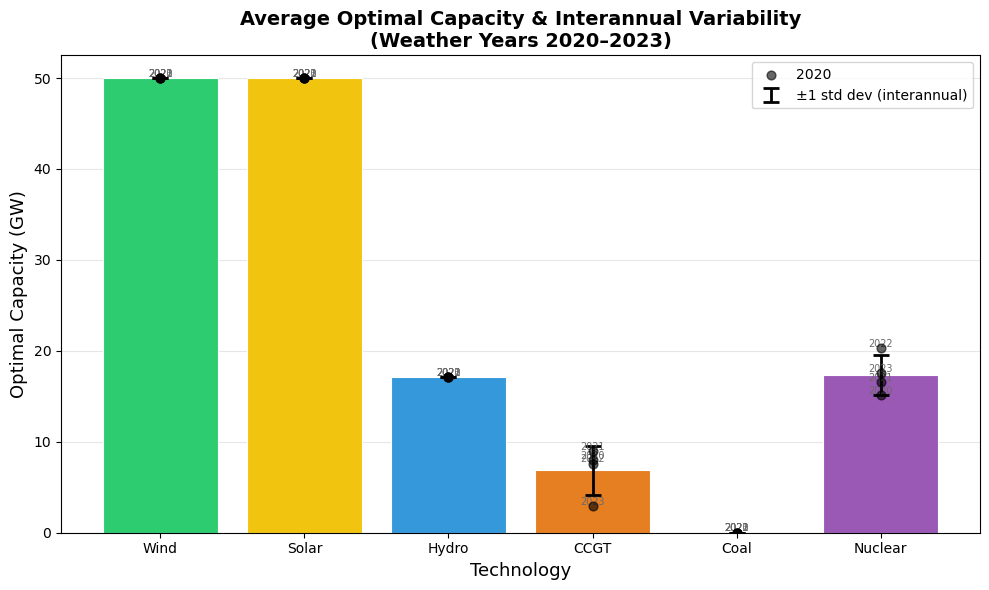

Chart saved.


In [7]:
means = cap_df.mean()
stds  = cap_df.std()

fig, ax = plt.subplots(figsize=(10, 6))
colors  = [color_map.get(t, 'gray') for t in techs]

bars = ax.bar(techs, means[techs] / 1000, color=colors,
              edgecolor='white', linewidth=0.8, zorder=2)

ax.errorbar(techs, means[techs] / 1000, yerr=stds[techs] / 1000,
            fmt='none', color='black', capsize=6, capthick=2,
            elinewidth=2, zorder=3, label='±1 std dev (interannual)')

# Scatter individual year values
for j, yr in enumerate(YEARS):
    vals = [cap_df.loc[yr, t] / 1000 for t in techs]
    ax.scatter(techs, vals, zorder=4, s=40,
               color='black', alpha=0.6,
               label=str(yr) if j == 0 else '_nolegend_')
    for t_idx, t in enumerate(techs):
        ax.annotate(str(yr), (t_idx, vals[t_idx] + 0.15),
                    ha='center', fontsize=7, color='dimgray')

ax.set_xlabel('Technology', fontsize=13)
ax.set_ylabel('Optimal Capacity (GW)', fontsize=13)
ax.set_title('Average Optimal Capacity & Interannual Variability\n(Weather Years 2020–2023)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('./Plots/Interannual_variability/interannual_variability_errorbars.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

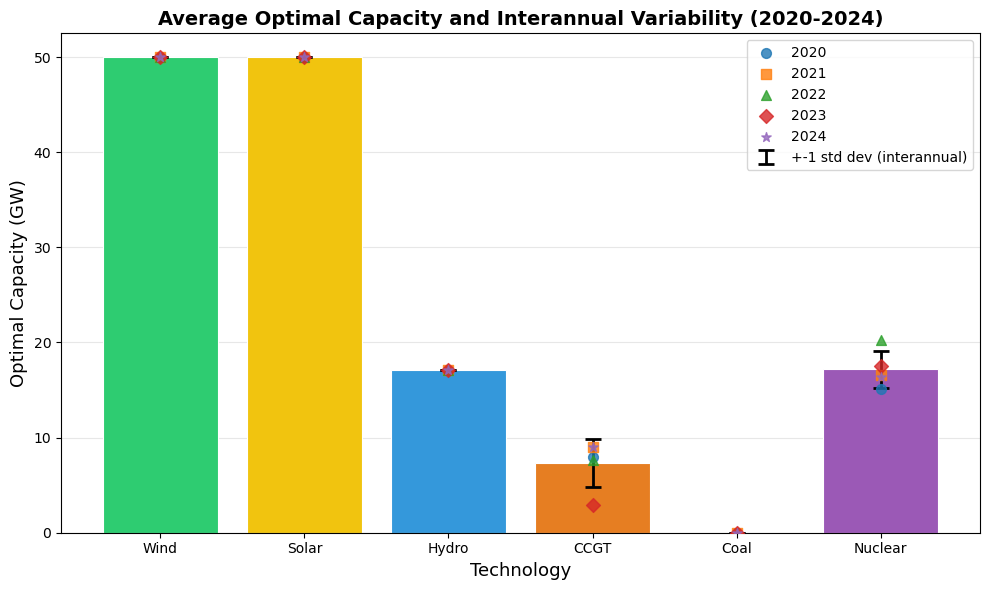

Error bar chart saved.


In [12]:
# Chart 7 – Average Capacity with Variability (Error Bars) including 2024
techs = ['Wind', 'Solar', 'Hydro', 'CCGT', 'Coal', 'Nuclear']
color_map = {
    'Wind':    '#2ecc71',
    'Solar':   '#f1c40f',
    'Hydro':   '#3498db',
    'CCGT':    '#e67e22',
    'Coal':    '#7f8c8d',
    'Nuclear': '#9b59b6',
}

# --- 2024 results from the original notebook ---
results_2024 = {
    "Wind":    50000.0,
    "Solar":   50000.0,
    "Hydro":   17097.0,
    "CCGT":    9058.0,
    "Coal":        0.0,
    "Nuclear": 16329.0,
}

all_years_eb   = YEARS + [2024]
all_results_eb = {**results_per_year, 2024: results_2024}

cap_eb = pd.DataFrame(
    {yr: {t: all_results_eb[yr].get(t, 0) for t in techs} for yr in all_years_eb}
).T

means = cap_eb.mean() / 1000
stds  = cap_eb.std()  / 1000

fig, ax = plt.subplots(figsize=(10, 6))
colors = [color_map[t] for t in techs]

ax.bar(techs, means[techs], color=colors, edgecolor='white', linewidth=0.8, zorder=2)

ax.errorbar(techs, means[techs], yerr=stds[techs],
            fmt='none', color='black', capsize=6, capthick=2,
            elinewidth=2, zorder=3, label='+-1 std dev (interannual)')

markers = ['o', 's', '^', 'D', '*']
for j, yr in enumerate(all_years_eb):
    vals = [cap_eb.loc[yr, t] / 1000 for t in techs]
    ax.scatter(techs, vals, zorder=4, s=50,
               marker=markers[j % len(markers)],
               label=str(yr), alpha=0.8)

ax.set_xlabel('Technology', fontsize=13)
ax.set_ylabel('Optimal Capacity (GW)', fontsize=13)
ax.set_title('Average Optimal Capacity and Interannual Variability (2020-2024)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('./Plots/Interannual_variability/variability_errorbars_2020_2024.png', dpi=150, bbox_inches='tight')
plt.show()
print('Error bar chart saved.')

## 8. Add 2024 Results and Plot All Years (GW + %)

In [13]:
all_years  = YEARS + [2024]
all_results = {**results_per_year, 2024: results_2024}
techs = ["Wind", "Solar", "Hydro", "CCGT", "Coal", "Nuclear"]

color_map = {
    "Wind":    "#2ecc71",
    "Solar":   "#f1c40f",
    "Hydro":   "#3498db",
    "CCGT":    "#e67e22",
    "Coal":    "#7f8c8d",
    "Nuclear": "#9b59b6",
}

cap_all = pd.DataFrame(
    {yr: {t: all_results[yr].get(t, 0) for t in techs} for yr in all_years}
).T
cap_all.index.name = "Year"
print(cap_all.round(0))


         Wind    Solar    Hydro    CCGT  Coal  Nuclear
Year                                                  
2020  50000.0  50000.0  17097.0  7986.0  -0.0  15128.0
2021  50000.0  50000.0  17097.0  8968.0  -0.0  16538.0
2022  50000.0  50000.0  17097.0  7610.0  -0.0  20307.0
2023  50000.0  50000.0  17097.0  2892.0  -0.0  17516.0
2024  50000.0  50000.0  17097.0  9058.0   0.0  16329.0


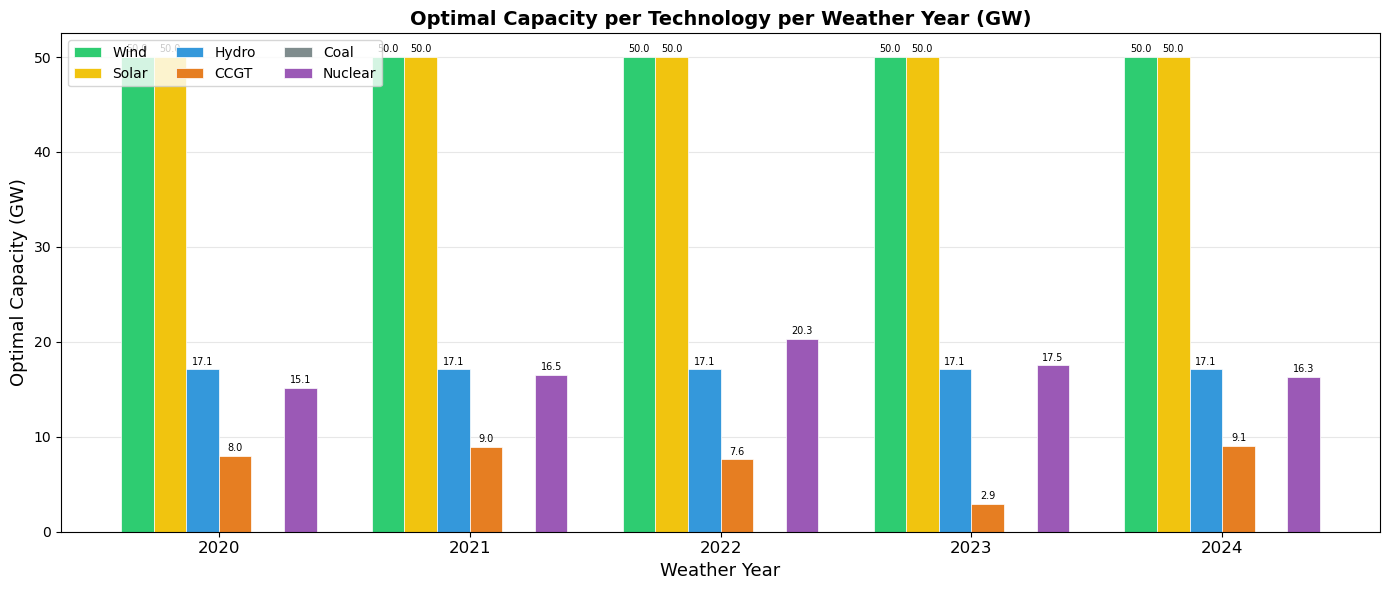

Plot GW saved.


In [14]:
# PLOT 1: Grouped bar chart in GW
x       = np.arange(len(all_years))
n_tech  = len(techs)
width   = 0.13
offsets = np.linspace(-(n_tech-1)/2, (n_tech-1)/2, n_tech) * width

fig, ax = plt.subplots(figsize=(14, 6))
for i, tech in enumerate(techs):
    values = [all_results[yr].get(tech, 0) / 1000 for yr in all_years]
    bars = ax.bar(x + offsets[i], values, width=width,
                  label=tech, color=color_map[tech],
                  edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        if val > 0.5:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([str(yr) for yr in all_years], fontsize=12)
ax.set_xlabel('Weather Year', fontsize=13)
ax.set_ylabel('Optimal Capacity (GW)', fontsize=13)
ax.set_title('Optimal Capacity per Technology per Weather Year (GW)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, ncol=3)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('./Plots/Interannual_variability/capacity_GW_all_years.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot GW saved.')


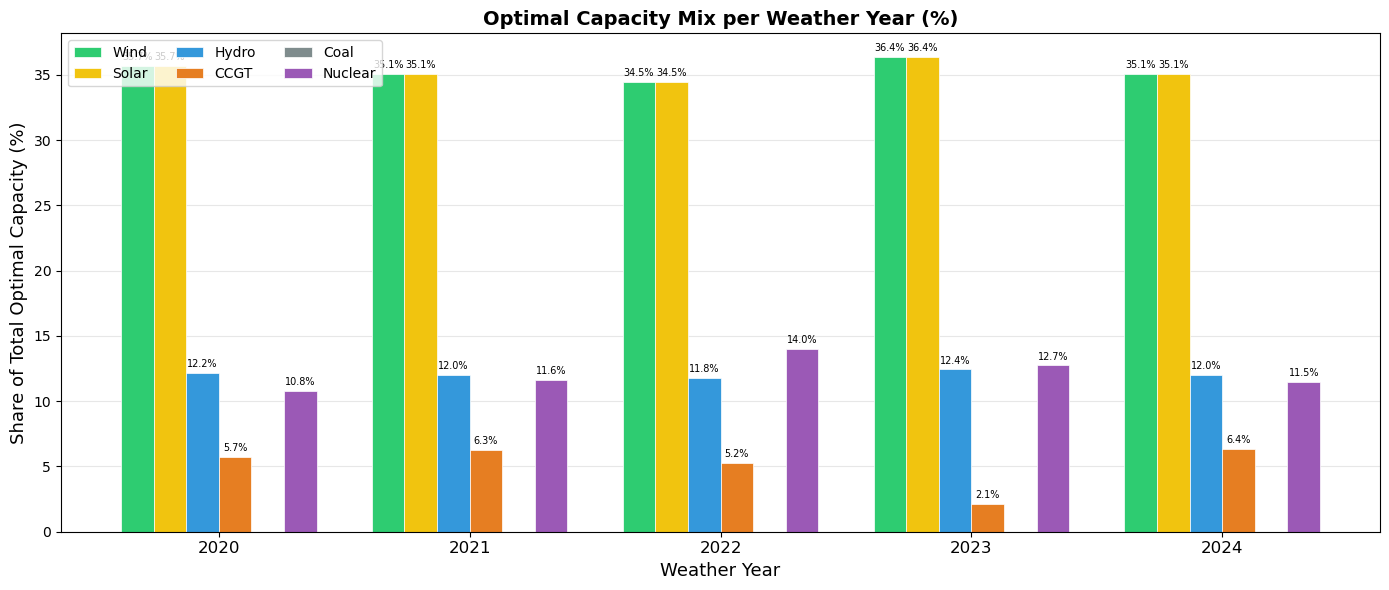

Plot % saved.


In [15]:
# PLOT 2: Grouped bar chart in %
cap_pct = cap_all.div(cap_all.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
for i, tech in enumerate(techs):
    values = [cap_pct.loc[yr, tech] for yr in all_years]
    bars = ax.bar(x + offsets[i], values, width=width,
                  label=tech, color=color_map[tech],
                  edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        if val > 1:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([str(yr) for yr in all_years], fontsize=12)
ax.set_xlabel('Weather Year', fontsize=13)
ax.set_ylabel('Share of Total Optimal Capacity (%)', fontsize=13)
ax.set_title('Optimal Capacity Mix per Weather Year (%)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, ncol=3)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('./Plots/Interannual_variability/capacity_PCT_all_years.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot % saved.')
